# LangGraph: Building Production AI Agents
## Comprehensive Guide with Code Examples
**Focus: Multi-Agent Systems, State Management, Reasoning Loops**

---

This notebook covers:
- LangGraph fundamentals
- State management & persistence
- Agents with ReAct pattern
- Tool integration & validation
- Error handling & recovery
- Production patterns
- Real-world examples

# 1. LANGGRAPH FUNDAMENTALS

In [2]:
"""LangGraph Basics: State Graphs and Node Execution

LangGraph = NetworkX + LLMs
Build: Nodes (actions) + Edges (transitions) + State (shared data)

Difference from LangChain:
- LangChain: Sequential chains (linear flow)
- LangGraph: DAG graphs (complex logic, branching, loops)
"""

from typing import TypedDict, Literal
from langgraph.graph import StateGraph, END
import json

# ============= STEP 1: DEFINE STATE =============
class AgentState(TypedDict):
    """Shared state across all nodes.
    
    Think of this as the 'working memory' of your agent.
    All nodes read from and write to this state.
    """
    messages: list  # Conversation history (list of dicts)
    current_task: str  # What we're working on
    tools_used: list  # Tools we've called
    result: str  # Final result
    iterations: int  # Loop count (prevent infinite loops)

# ============= STEP 2: DEFINE NODES (Functions) =============
def node_analyze(state: AgentState) -> AgentState:
    """Analyze the task and plan approach."""
    print(f'[ANALYZE] Task: {state["current_task"]}')
    
    # Add message to history
    state["messages"].append({
        "role": "agent",
        "content": f"Analyzing task: {state['current_task']}"
    })
    state["iterations"] += 1
    
    return state

def node_execute(state: AgentState) -> AgentState:
    """Execute the plan."""
    print(f'[EXECUTE] Working on: {state["current_task"]}')
    
    state["messages"].append({
        "role": "agent",
        "content": "Executing plan"
    })
    state["result"] = "Execution complete"
    
    return state

# ============= STEP 3: BUILD GRAPH =============
def build_simple_graph():
    """Build a simple sequential graph."""
    graph = StateGraph(AgentState)
    
    # Add nodes
    graph.add_node("analyze", node_analyze)
    graph.add_node("execute", node_execute)
    
    # Add edges (connections)
    graph.add_edge("analyze", "execute")
    graph.add_edge("execute", END)  # End of execution
    
    # Set entry point
    graph.set_entry_point("analyze")
    
    # Compile to runnable
    return graph.compile()

# ============= STEP 4: RUN THE GRAPH =============
app = build_simple_graph()

initial_state = {
    "messages": [],
    "current_task": "Solve a math problem",
    "tools_used": [],
    "result": "",
    "iterations": 0
}

result = app.invoke(initial_state)
print(f"Final Result: {result['result']}")
print(f"Iterations: {result['iterations']}")
print(f"Messages: {result['messages']}")

# ============= INTERVIEW TIPS =============
# ✓ State: immutable input/output for each node
# ✓ Nodes: pure functions (no side effects)
# ✓ Edges: define control flow (sequential, conditional, loops)
# ✓ END: special node indicating graph completion
# ✓ Compile: converts graph to executable app

[ANALYZE] Task: Solve a math problem
[EXECUTE] Working on: Solve a math problem
Final Result: Execution complete
Iterations: 1
Messages: [{'role': 'agent', 'content': 'Analyzing task: Solve a math problem'}, {'role': 'agent', 'content': 'Executing plan'}]


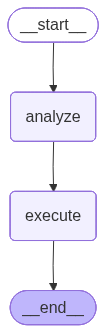

In [3]:
app

# 2. CONDITIONAL EDGES & BRANCHING

[ANALYZE] Task: Find information
Search task result: Search result found
[ANALYZE] Task: Calculate 2+2
Math task result: Calculation complete: 42


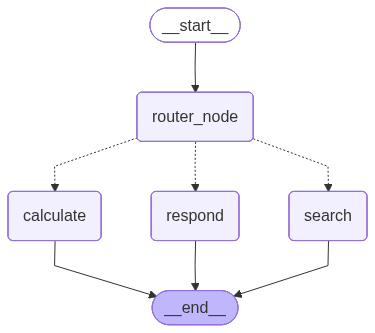

In [5]:
"""Conditional edges: route based on state.

Real-world: Agent decides which action to take next
- If task needs search: go to search node
- If task needs calculation: go to calculator node
- If ready to respond: go to response node
"""

from typing import Literal

# ============= DEFINE ROUTER FUNCTION =============
def router(state: AgentState) -> Literal["search", "calculate", "respond"]:
    """Route based on task type.
    
    Return value determines next node to visit.
    """
    task = state["current_task"].lower()
    
    if "search" in task or "find" in task:
        return "search"
    elif "calculate" in task or "math" in task:
        return "calculate"
    else:
        return "respond"

# ============= DEFINE CONDITIONAL NODES =============
def node_search(state: AgentState) -> AgentState:
    """Search for information."""
    state["messages"].append({"role": "agent", "content": "Searching..."})
    state["result"] = "Search result found"
    return state

def node_calculate(state: AgentState) -> AgentState:
    """Perform calculations."""
    state["messages"].append({"role": "agent", "content": "Calculating..."})
    state["result"] = "Calculation complete: 42"
    return state

def node_respond(state: AgentState) -> AgentState:
    """Generate response."""
    state["messages"].append({"role": "agent", "content": "Responding..."})
    state["result"] = "Here's your response"
    return state

# ============= BUILD GRAPH WITH CONDITIONAL EDGES =============
def build_conditional_graph():
    """Graph with branching logic."""
    graph = StateGraph(AgentState)
    
    # Add nodes
    graph.add_node("router_node", node_analyze)  # Entry point
    graph.add_node("search", node_search)
    graph.add_node("calculate", node_calculate)
    graph.add_node("respond", node_respond)
    
    # Set entry
    graph.set_entry_point("router_node")
    
    # Add conditional edges (branching)
    # After router_node, decision based on router() output
    graph.add_conditional_edges(
        "router_node",  # Source node
        router,          # Function that returns next node name
        {
            "search": "search",      # If router returns "search"
            "calculate": "calculate",  # If router returns "calculate"
            "respond": "respond"      # If router returns "respond"
        }
    )
    
    # All paths lead to END
    graph.add_edge("search", END)
    graph.add_edge("calculate", END)
    graph.add_edge("respond", END)
    
    return graph.compile()

# ============= TEST =============
app = build_conditional_graph()

# Test search task
state1 = {"messages": [], "current_task": "Find information", "tools_used": [], "result": "", "iterations": 0}
result1 = app.invoke(state1)
print(f"Search task result: {result1['result']}")

# Test math task
state2 = {"messages": [], "current_task": "Calculate 2+2", "tools_used": [], "result": "", "iterations": 0}
result2 = app.invoke(state2)
print(f"Math task result: {result2['result']}")
app
# ============= INTERVIEW TIPS =============
# ✓ Conditional edges: return value from function becomes next node
# ✓ Mapping: dict maps return values to node names
# ✓ Agent decides which path: search? calculate? respond?
# ✓ Each path is independent but starts from same state

# 3. LOOPS & ITERATIONS (ReAct PATTERN)

[THINK] Question: What's the weather like?
[THINK] Observations so far: 
[ACT] Action: weather_search
[ACT] Input: New York

Final answer: Weather in New York: 72F, Sunny


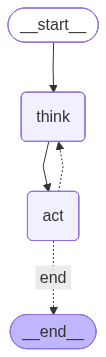

In [8]:
"""ReAct = Reasoning + Acting

Agent loops:
1. Reason about problem (think)
2. Choose tool to call (act)
3. Observe result
4. Repeat until done

This is the core of agentic AI!
"""

from typing import Literal

# ============= REACT STATE =============
class ReactState(TypedDict):
    """State for ReAct loop."""
    question: str
    reasoning: str  # Agent's thought process
    action: str  # Tool to use
    action_input: str  # Input to tool
    observation: str  # Result from tool
    answer: str  # Final answer
    iterations: int  # Prevent infinite loops
    max_iterations: int  # Safety limit

# ============= REACT NODES =============
def think_node(state: ReactState) -> ReactState:
    """Agent thinks about what to do next."""
    print(f"[THINK] Question: {state['question']}")
    print(f"[THINK] Observations so far: {state['observation']}")
    
    # Simulate LLM reasoning
    if "weather" in state["question"].lower():
        state["reasoning"] = "User asking about weather. Need to use weather tool."
        state["action"] = "weather_search"
        state["action_input"] = "New York"
    elif "calculate" in state["question"].lower():
        state["reasoning"] = "Math problem. Need calculator."
        state["action"] = "calculator"
        state["action_input"] = "2+2"
    else:
        state["reasoning"] = "Can answer directly."
        state["action"] = "respond"
        state["action_input"] = state["question"]
    
    return state

def act_node(state: ReactState) -> ReactState:
    """Execute the action (call tool)."""
    print(f"[ACT] Action: {state['action']}")
    print(f"[ACT] Input: {state['action_input']}")
    
    # Count one loop iteration inside a node (state updates persist here)
    state["iterations"] += 1
    
    # Simulate tool calls
    if state["action"] == "weather_search":
        state["observation"] = "Weather in New York: 72F, Sunny"
        state["answer"] = state["observation"]
    elif state["action"] == "calculator":
        state["observation"] = "Result: 4"
        state["answer"] = state["observation"]
    elif state["action"] == "respond":
        state["answer"] = f"Answer to {state['question']}: I'd be happy to help!"
        state["observation"] = "Response generated"
    
    return state

def should_continue(state: ReactState) -> Literal["think", "end"]:
    """Decide: continue loop or end?"""
    # Stop if we have answer
    if state["answer"]:
        return "end"
    
    # Stop if max iterations reached
    if state["iterations"] >= state["max_iterations"]:
        print("Max iterations reached!")
        return "end"
    
    # Otherwise continue
    return "think"

# ============= BUILD REACT GRAPH =============
def build_react_graph():
    """Build ReAct loop."""
    graph = StateGraph(ReactState)
    
    graph.add_node("think", think_node)
    graph.add_node("act", act_node)
    
    graph.set_entry_point("think")
    
    # think -> act
    graph.add_edge("think", "act")
    
    # act -> should_continue (conditional)
    graph.add_conditional_edges(
        "act",
        should_continue,
        {
            "think": "think",  # Loop back
            "end": END  # Done
        }
    )
    
    return graph.compile()

# ============= TEST =============
app = build_react_graph()
initial_state = {
    "question": "What's the weather like?",
    "reasoning": "",
    "action": "",
    "action_input": "",
    "observation": "",
    "answer": "",
    "iterations": 0,
    "max_iterations": 5
}
result = app.invoke(initial_state, config={"recursion_limit": 100})
print(f"\nFinal answer: {result['answer']}")
app
# ============= INTERVIEW TIPS =============
# ✓ Think-Act loop: agent reasons then executes
# ✓ Observe result and decide next step
# ✓ Max iterations: CRITICAL to prevent infinite loops
# ✓ Termination condition: when goal achieved or max iterations

# 4. TOOL INTEGRATION & VALIDATION

In [ ]:
"""Integrating tools (functions) that agent can call.

Tools: calculator, web search, database query, API calls, etc.
Agent decides when and how to call tools.
"""

import json
from typing import Any

# ============= DEFINE TOOLS =============
class Tool:
    """Base tool class."""
    def __init__(self, name: str, description: str, func):
        self.name = name
        self.description = description
        self.func = func
    
    def execute(self, *args, **kwargs):
        """Call the tool with validation."""
        try:
            result = self.func(*args, **kwargs)
            return {"status": "success", "result": result}
        except Exception as e:
            return {"status": "error", "error": str(e)}

# ============= CONCRETE TOOLS =============
def calculator_func(expression: str) -> float:
    """Simple calculator (safe: only numbers and ops)."""
    # Validate input (prevent injection)
    allowed_chars = set('0123456789+-*/(). ')
    if not all(c in allowed_chars for c in expression):
        raise ValueError(f"Invalid expression: {expression}")
    
    return eval(expression)  # Safe after validation

def search_func(query: str) -> str:
    """Simulate web search."""
    # In production: use real API (Google, Bing, etc.)
    results = {
        "weather": "Weather in NYC: 72F, Sunny",
        "python": "Python is a programming language",
        "ai": "AI is artificial intelligence"
    }
    return results.get(query.lower(), "No results found")

def database_func(query: str) -> list:
    """Simulate database query."""
    # In production: connect to real database
    if "select" in query.lower():
        return [{"id": 1, "name": "Alice"}, {"id": 2, "name": "Bob"}]
    return []

# ============= TOOL REGISTRY =============
class ToolRegistry:
    """Manage available tools."""
    def __init__(self):
        self.tools = {}
    
    def register(self, name: str, description: str, func):
        """Register a tool."""
        self.tools[name] = Tool(name, description, func)
    
    def get_tool(self, name: str) -> Tool:
        """Get tool by name."""
        if name not in self.tools:
            raise ValueError(f"Tool not found: {name}")
        return self.tools[name]
    
    def list_tools(self) -> str:
        """Get tool descriptions for LLM."""
        descriptions = []
        for name, tool in self.tools.items():
            descriptions.append(f"{name}: {tool.description}")
        return "\n".join(descriptions)
    
    def call_tool(self, name: str, *args, **kwargs):
        """Call a tool with error handling."""
        tool = self.get_tool(name)
        return tool.execute(*args, **kwargs)

# ============= SETUP & TEST =============
# registry = ToolRegistry()
# registry.register("calculator", "Performs math calculations", calculator_func)
# registry.register("search", "Searches the web for information", search_func)
# registry.register("database", "Queries the database", database_func)
# 
# # Get tool info
# print("Available Tools:")
# print(registry.list_tools())
# 
# # Call tools
# print("\nCalling calculator:")
# result = registry.call_tool("calculator", "2+2*3")
# print(f"Result: {result}")
# 
# print("\nCalling search:")
# result = registry.call_tool("search", "weather")
# print(f"Result: {result}")

# ============= INTERVIEW TIPS =============
# ✓ Tool validation: prevent injection/errors
# ✓ Error handling: return clear error messages
# ✓ Tool descriptions: help LLM decide when to use
# ✓ Tool registry: manage all available tools
# ✓ Return structured output: {status, result/error}

# 5. PERSISTENCE & CHECKPOINTING

In [ ]:
"""Checkpoint graph state: pause and resume execution.

Use cases:
- Human-in-the-loop: agent pauses for approval
- Long-running workflows: save progress
- Multi-turn conversations: maintain state
- Error recovery: resume from checkpoint
"""

from langgraph.checkpoint.sqlite import SqliteSaver
from datetime import datetime

# ============= MEMORY CHECKPOINTER =============
class MemoryCheckpointer:
    """Simple in-memory checkpoint storage."""
    def __init__(self):
        self.checkpoints = {}  # thread_id -> list of states
    
    def save(self, thread_id: str, state: dict, step: int):
        """Save checkpoint."""
        if thread_id not in self.checkpoints:
            self.checkpoints[thread_id] = []
        
        checkpoint = {
            "state": state,
            "step": step,
            "timestamp": datetime.now().isoformat()
        }
        self.checkpoints[thread_id].append(checkpoint)
    
    def load(self, thread_id: str, step: int = None) -> dict:
        """Load checkpoint.
        
        step=None: load latest
        step=N: load specific step
        """
        if thread_id not in self.checkpoints:
            return None
        
        if step is None:
            # Latest
            return self.checkpoints[thread_id][-1]["state"]
        else:
            # Specific step
            for cp in self.checkpoints[thread_id]:
                if cp["step"] == step:
                    return cp["state"]
        return None
    
    def list_checkpoints(self, thread_id: str) -> list:
        """List all checkpoints for a thread."""
        if thread_id not in self.checkpoints:
            return []
        return [(cp["step"], cp["timestamp"]) for cp in self.checkpoints[thread_id]]

# ============= GRAPH WITH CHECKPOINTING =============
def build_graph_with_checkpoint():
    """Graph that can be paused and resumed."""
    
    class PersistentState(TypedDict):
        user_input: str
        agent_response: str
        requires_approval: bool
        approved: bool
        step: int
    
    def process_node(state: PersistentState) -> PersistentState:
        """Process user input."""
        state["agent_response"] = f"Processing: {state['user_input']}"
        state["requires_approval"] = True  # Needs human review
        state["step"] += 1
        return state
    
    def approval_node(state: PersistentState) -> PersistentState:
        """Wait for human approval (pauses here)."""
        if state["requires_approval"]:
            print(f"Awaiting approval for: {state['agent_response']}")
            # In production: return and wait for external approval
            # Graph pauses here
        state["step"] += 1
        return state
    
    def final_node(state: PersistentState) -> PersistentState:
        """Final step after approval."""
        if state["approved"]:
            state["agent_response"] = f"Approved: {state['agent_response']}"
        state["step"] += 1
        return state
    
    graph = StateGraph(PersistentState)
    graph.add_node("process", process_node)
    graph.add_node("approval", approval_node)
    graph.add_node("final", final_node)
    
    graph.set_entry_point("process")
    graph.add_edge("process", "approval")
    graph.add_edge("approval", "final")
    graph.add_edge("final", END)
    
    return graph.compile()

# ============= USAGE =============
# app = build_graph_with_checkpoint()
# checkpointer = MemoryCheckpointer()
# thread_id = "conversation_123"
# 
# # First run: process request
# initial_state = {
#     "user_input": "Transfer $1000",
#     "agent_response": "",
#     "requires_approval": False,
#     "approved": False,
#     "step": 0
# }
# 
# result = app.invoke(initial_state)
# checkpointer.save(thread_id, result, result["step"])
# 
# # Later: resume with approval
# resumed_state = checkpointer.load(thread_id)
# resumed_state["approved"] = True
# result = app.invoke(resumed_state)

# ============= INTERVIEW TIPS =============
# ✓ Thread ID: unique conversation/session identifier
# ✓ Checkpoint: save state at each step
# ✓ Resume: load checkpoint and continue
# ✓ Use case: human-in-the-loop workflows
# ✓ In production: use persistent database (SQLite, PostgreSQL)

# 6. ERROR HANDLING & RECOVERY

In [ ]:
"""Robust error handling in production agents."""

from typing import Optional
import traceback

# ============= ERROR STATE =============
class RobustState(TypedDict):
    task: str
    result: str
    error: Optional[str]
    error_count: int
    max_retries: int
    last_attempted_action: str

# ============= ERROR HANDLING NODES =============
def try_action(state: RobustState) -> RobustState:
    """Execute action with error handling."""
    try:
        print(f"Attempting: {state['task']}")
        # Simulate action
        if "fail" in state["task"].lower():
            raise ValueError("Intentional failure for demo")
        
        state["result"] = "Success!"
        state["error"] = None
        state["error_count"] = 0
    
    except Exception as e:
        print(f"Error: {str(e)}")
        state["error"] = str(e)
        state["error_count"] += 1
        state["last_attempted_action"] = state["task"]
    
    return state

def handle_error(state: RobustState) -> RobustState:
    """Handle error: retry, fallback, or fail."""
    print(f"Error handler triggered. Count: {state['error_count']}")
    
    if state["error_count"] < state["max_retries"]:
        print("Retrying...")
        # Could modify task for retry (e.g., different parameters)
        state["task"] = f"Retry: {state['task']}"
    else:
        print("Max retries exceeded. Executing fallback.")
        state["result"] = "Fallback result"
        state["error"] = None
    
    return state

def should_retry(state: RobustState) -> Literal["try_action", "end"]:
    """Decide: retry or give up?"""
    if state["error"] is None:
        # Success
        return "end"
    elif state["error_count"] < state["max_retries"]:
        # Retry
        return "try_action"
    else:
        # Give up
        return "end"

# ============= BUILD ROBUST GRAPH =============
def build_robust_graph():
    """Graph with error handling and retries."""
    graph = StateGraph(RobustState)
    
    graph.add_node("try_action", try_action)
    graph.add_node("handle_error", handle_error)
    
    graph.set_entry_point("try_action")
    
    # After try_action, check for error
    graph.add_conditional_edges(
        "try_action",
        lambda state: "handle_error" if state["error"] else "end",
        {
            "handle_error": "handle_error",
            "end": END
        }
    )
    
    # After handle_error, decide to retry
    graph.add_conditional_edges(
        "handle_error",
        should_retry,
        {
            "try_action": "try_action",
            "end": END
        }
    )
    
    return graph.compile()

# ============= INTERVIEW TIPS =============
# ✓ Try-except in each node
# ✓ Store error info in state
# ✓ Retry logic: max_retries prevents infinite loops
# ✓ Fallback options: alternative strategies
# ✓ Log errors for debugging
# ✓ State transitions on error vs success

# 7. MULTI-AGENT SYSTEMS

In [9]:
"""Multiple agents working together.

Patterns:
- Orchestrator: main agent delegates to specialists
- Peers: agents communicate with each other
- Supervisor: one agent manages others
"""

# ============= MULTI-AGENT STATE =============
class MultiAgentState(TypedDict):
    task: str
    research_result: str  # Agent 1
    analysis_result: str  # Agent 2
    final_answer: str
    coordination_log: list

# ============= SPECIALIST AGENTS =============
def researcher_agent(state: MultiAgentState) -> MultiAgentState:
    """Agent 1: Research specialist."""
    print(f"[RESEARCHER] Researching: {state['task']}")
    state["research_result"] = "Research findings: ..."
    state["coordination_log"].append("Researcher completed")
    return state

def analyst_agent(state: MultiAgentState) -> MultiAgentState:
    """Agent 2: Analysis specialist."""
    print(f"[ANALYST] Analyzing: {state['research_result']}")
    state["analysis_result"] = "Analysis: ..."
    state["coordination_log"].append("Analyst completed")
    return state

def synthesizer_agent(state: MultiAgentState) -> MultiAgentState:
    """Agent 3: Synthesize results."""
    print(f"[SYNTHESIZER] Combining results")
    state["final_answer"] = (
        f"Combined result: {state['research_result']} + {state['analysis_result']}"
    )
    state["coordination_log"].append("Synthesizer completed")
    return state

# ============= ORCHESTRATOR PATTERN =============
def build_orchestrator_graph():
    """Main agent coordinates specialists."""
    graph = StateGraph(MultiAgentState)
    
    graph.add_node("researcher", researcher_agent)
    graph.add_node("analyst", analyst_agent)
    graph.add_node("synthesizer", synthesizer_agent)
    
    graph.set_entry_point("researcher")
    
    # Sequential: research -> analyze -> synthesize
    graph.add_edge("researcher", "analyst")
    graph.add_edge("analyst", "synthesizer")
    graph.add_edge("synthesizer", END)
    
    return graph.compile()

# ============= PARALLEL AGENTS =============
"""For parallel execution (research + analysis simultaneously):

from concurrent.futures import ThreadPoolExecutor

def run_agents_in_parallel(state):
    with ThreadPoolExecutor(max_workers=2) as executor:
        future1 = executor.submit(researcher_agent, state.copy())
        future2 = executor.submit(analyst_agent, state.copy())
        
        result1 = future1.result()
        result2 = future2.result()
        
        # Merge results
        merged_state = state.copy()
        merged_state['research_result'] = result1['research_result']
        merged_state['analysis_result'] = result2['analysis_result']
        return merged_state
"""

# ============= INTERVIEW TIPS =============
# ✓ Orchestrator: one main agent delegates
# ✓ Sequential: one agent after another
# ✓ Parallel: multiple agents simultaneously (faster)
# ✓ Communication: agents update shared state
# ✓ Coordination log: track agent execution order

"For parallel execution (research + analysis simultaneously):\n\nfrom concurrent.futures import ThreadPoolExecutor\n\ndef run_agents_in_parallel(state):\n    with ThreadPoolExecutor(max_workers=2) as executor:\n        future1 = executor.submit(researcher_agent, state.copy())\n        future2 = executor.submit(analyst_agent, state.copy())\n        \n        result1 = future1.result()\n        result2 = future2.result()\n        \n        # Merge results\n        merged_state = state.copy()\n        merged_state['research_result'] = result1['research_result']\n        merged_state['analysis_result'] = result2['analysis_result']\n        return merged_state\n"

# 8. LANGGRAPH + LLM INTEGRATION

In [ ]:
"""Integrating LangGraph with LLMs (real agents)."""

# ============= LLM-POWERED AGENT STATE =============
class LLMAgentState(TypedDict):
    messages: list  # List of {role, content} dicts
    tools: list  # Available tools
    tool_results: list  # Results from tool calls
    final_answer: str

# ============= EXAMPLE: LLM REASONING NODE =============
def llm_think_node(state: LLMAgentState) -> LLMAgentState:
    """LLM generates reasoning and tool calls.
    
    In production:
    llm = ChatOpenAI(model="gpt-4")
    response = llm.invoke(state['messages'])
    
    Parse response for:
    - Reasoning (what to do)
    - Tool calls (which tools to use)
    - Final answer (when done)
    """
    
    # Simulate LLM response
    last_message = state["messages"][-1]["content"] if state["messages"] else ""
    
    # LLM decides: should we use a tool or respond?
    if "weather" in last_message.lower():
        # Decision: use weather tool
        state["messages"].append({
            "role": "assistant",
            "content": "I'll check the weather for you.",
            "tool_use": {
                "tool_name": "weather_search",
                "tool_input": {"location": "New York"}
            }
        })
    else:
        # Decision: respond directly
        state["messages"].append({
            "role": "assistant",
            "content": "I can help with that!"
        })
        state["final_answer"] = "Task complete"
    
    return state

def llm_tool_execution_node(state: LLMAgentState) -> LLMAgentState:
    """Execute tools that LLM decided to use."""
    
    # Find last message with tool_use
    for msg in reversed(state["messages"]):
        if "tool_use" in msg:
            tool_name = msg["tool_use"]["tool_name"]
            tool_input = msg["tool_use"]["tool_input"]
            
            # Execute tool
            if tool_name == "weather_search":
                result = f"Weather in {tool_input['location']}: 72F, Sunny"
            else:
                result = "Tool not found"
            
            # Add result to messages
            state["messages"].append({
                "role": "tool",
                "content": result
            })
            break
    
    return state

def should_continue_llm(state: LLMAgentState) -> Literal["think", "end"]:
    """LLM decides: continue or stop?"""
    
    # Check if final_answer is set
    if state.get("final_answer"):
        return "end"
    
    # Check if last message is from tool (needs processing)
    if state["messages"] and state["messages"][-1]["role"] == "tool":
        return "think"  # Let LLM process result
    
    return "end"

# ============= BUILD LLM-POWERED GRAPH =============
def build_llm_agent_graph():
    """Agent powered by LLM."""
    graph = StateGraph(LLMAgentState)
    
    graph.add_node("think", llm_think_node)
    graph.add_node("execute_tool", llm_tool_execution_node)
    
    graph.set_entry_point("think")
    
    # think -> check if tool needed
    graph.add_conditional_edges(
        "think",
        lambda state: "execute_tool" if any(
            "tool_use" in msg for msg in state["messages"]
        ) else "end",
        {"execute_tool": "execute_tool", "end": END}
    )
    
    # execute_tool -> think (loop)
    graph.add_edge("execute_tool", "think")
    
    return graph.compile()

# ============= INTERVIEW TIPS =============
# ✓ LLM generates reasoning (transparency)
# ✓ LLM decides which tools to use
# ✓ Loop: think -> execute -> think
# ✓ Stop when LLM provides final answer
# ✓ Max iterations to prevent infinite loops
# ✓ Message format: role (user/assistant/tool) + content

# 9. PRODUCTION PATTERNS & BEST PRACTICES

In [ ]:
"""Production patterns for LangGraph agents."""

"""PATTERN 1: CIRCUIT BREAKER
Stop execution if too many errors occur.
"""

class CircuitBreaker:
    def __init__(self, failure_threshold=5, reset_timeout=60):
        self.failure_count = 0
        self.failure_threshold = failure_threshold
        self.is_open = False
        self.reset_timeout = reset_timeout
        self.last_failure_time = None
    
    def record_failure(self):
        """Record a failure."""
        self.failure_count += 1
        if self.failure_count >= self.failure_threshold:
            self.is_open = True
            print(f"Circuit breaker OPEN after {self.failure_count} failures")
    
    def can_execute(self) -> bool:
        """Can we execute or circuit is open?"""
        if not self.is_open:
            return True
        
        # Check if reset timeout passed
        # (In production: check actual time)
        return False
    
    def reset(self):
        """Reset circuit breaker."""
        self.failure_count = 0
        self.is_open = False
        print("Circuit breaker RESET")

"""PATTERN 2: TIMEOUT
Prevent long-running nodes from blocking.
"""

import time
from functools import wraps

def with_timeout(seconds):
    """Decorator: timeout for node execution."""
    def decorator(func):
        @wraps(func)
        def wrapper(state, *args, **kwargs):
            start = time.time()
            try:
                result = func(state, *args, **kwargs)
                elapsed = time.time() - start
                if elapsed > seconds:
                    print(f"WARNING: {func.__name__} took {elapsed:.2f}s (limit: {seconds}s)")
                return result
            except Exception as e:
                print(f"Node execution failed: {e}")
                raise
        return wrapper
    return decorator

"""PATTERN 3: LOGGING & MONITORING"""

class AgentMonitor:
    def __init__(self):
        self.execution_log = []
    
    def log_node_execution(self, node_name: str, state_size: int, duration: float):
        """Log node execution."""
        self.execution_log.append({
            "node": node_name,
            "state_size": state_size,
            "duration": duration,
            "timestamp": time.time()
        })
    
    def get_stats(self):
        """Get execution statistics."""
        if not self.execution_log:
            return {}
        
        durations = [log["duration"] for log in self.execution_log]
        return {
            "total_nodes_executed": len(self.execution_log),
            "total_duration": sum(durations),
            "avg_node_duration": sum(durations) / len(durations),
            "slowest_node": max(self.execution_log, key=lambda x: x["duration"])["node"],
            "slowest_duration": max(durations)
        }

"""PATTERN 4: STATE VALIDATION"""

def validate_state(required_keys: list):
    """Decorator: validate state has required keys."""
    def decorator(func):
        @wraps(func)
        def wrapper(state, *args, **kwargs):
            for key in required_keys:
                if key not in state:
                    raise ValueError(f"Missing required state key: {key}")
            return func(state, *args, **kwargs)
        return wrapper
    return decorator

# Usage
@validate_state(["messages", "task"])
def example_node(state):
    """Node that requires 'messages' and 'task'."""
    return state

"""PATTERN 5: DEAD LETTER QUEUE
Failed requests go to queue for manual review.
"""

class DeadLetterQueue:
    def __init__(self):
        self.failed_items = []
    
    def add(self, item: dict, reason: str):
        """Add failed item to DLQ."""
        self.failed_items.append({
            "item": item,
            "reason": reason,
            "timestamp": time.time()
        })
    
    def process(self) -> list:
        """Get items for manual review."""
        return self.failed_items

# ============= INTERVIEW TIPS =============
# ✓ Circuit breaker: stop if too many failures
# ✓ Timeout: prevent hanging requests
# ✓ Logging: track every node execution
# ✓ Monitoring: metrics (latency, errors, throughput)
# ✓ Validation: ensure state correctness
# ✓ DLQ: capture failures for investigation

# 10. REAL-WORLD EXAMPLE: RESEARCH AGENT

In [ ]:
"""Complete example: Research agent that answers questions.

Workflow:
1. User asks question
2. Agent plans research strategy
3. Agent searches for information
4. Agent analyzes findings
5. Agent returns answer with sources
"""

from typing import Literal

# ============= STATE =============
class ResearchAgentState(TypedDict):
    user_query: str
    research_plan: str
    search_queries: list
    search_results: list
    analysis: str
    final_answer: str
    sources: list
    iteration: int
    max_iterations: int

# ============= NODES =============
def planning_node(state: ResearchAgentState) -> ResearchAgentState:
    """Plan research strategy."""
    print(f"[PLANNING] Query: {state['user_query']}")
    
    # LLM would generate plan
    state["research_plan"] = "Search for recent developments in AI safety"
    state["search_queries"] = [
        "AI safety latest research",
        "alignment problem in AI",
        "AI risk mitigation strategies"
    ]
    
    return state

def search_node(state: ResearchAgentState) -> ResearchAgentState:
    """Search for information."""
    print(f"[SEARCH] Executing {len(state['search_queries'])} queries")
    
    # Simulate search results
    state["search_results"] = [
        {"title": "AI Safety Overview", "snippet": "..."},
        {"title": "Alignment Research", "snippet": "..."}
    ]
    state["sources"] = ["openai.com", "anthropic.com", "arxiv.org"]
    
    return state

def analysis_node(state: ResearchAgentState) -> ResearchAgentState:
    """Analyze search results."""
    print(f"[ANALYSIS] Analyzing {len(state['search_results'])} results")
    
    # LLM would synthesize findings
    state["analysis"] = """
    Based on latest research:
    1. AI safety is critical research area
    2. Multiple approaches being explored
    3. Interdisciplinary collaboration increasing
    """
    
    return state

def answer_node(state: ResearchAgentState) -> ResearchAgentState:
    """Generate final answer."""
    print(f"[ANSWER] Generating response")
    
    state["final_answer"] = f"""
    Question: {state['user_query']}
    
    Analysis: {state['analysis']}
    
    Sources: {', '.join(state['sources'])}
    """
    
    return state

# ============= CONDITIONAL ROUTER =============
def need_more_research(state: ResearchAgentState) -> Literal["search", "answer"]:
    """Decide: search more or answer?"""
    # In production: LLM decides if more info needed
    if state["iteration"] < 2:  # Maximum 2 searches
        return "search"
    return "answer"

# ============= BUILD GRAPH =============
def build_research_agent():
    """Complete research agent."""
    graph = StateGraph(ResearchAgentState)
    
    graph.add_node("planning", planning_node)
    graph.add_node("search", search_node)
    graph.add_node("analysis", analysis_node)
    graph.add_node("answer", answer_node)
    
    graph.set_entry_point("planning")
    
    # Flow
    graph.add_edge("planning", "search")
    graph.add_edge("search", "analysis")
    
    # Conditional: more research or answer?
    graph.add_conditional_edges(
        "analysis",
        need_more_research,
        {"search": "search", "answer": "answer"}
    )
    
    graph.add_edge("answer", END)
    
    return graph.compile()

# ============= USAGE =============
# app = build_research_agent()
# initial_state = {
#     "user_query": "What are latest advances in AI safety?",
#     "research_plan": "",
#     "search_queries": [],
#     "search_results": [],
#     "analysis": "",
#     "final_answer": "",
#     "sources": [],
#     "iteration": 0,
#     "max_iterations": 3
# }
# result = app.invoke(initial_state)
# print(result["final_answer"])

# ============= INTERVIEW TIPS =============
# ✓ Planning: break down complex task
# ✓ Search: gather information
# ✓ Analysis: synthesize findings
# ✓ Answer: respond to user
# ✓ Iteration: refine if needed
# ✓ Sources: cite references
# ✓ All traceable: every step logged

# 11. LANGGRAPH VS LANGCHAIN COMPARISON

In [ ]:
"""When to use LangGraph vs LangChain."""

comparison = """
╔════════════════════════════════════════════════════════════════════════╗
║                     LangChain vs LangGraph                             ║
╠═══════════════════════════════════════════════════════════════════════╗
║                                                                       ║
║  LangChain:                                                           ║
║  - Simple chains (sequential operations)                              ║
║  - Linear flow: step1 -> step2 -> step3                               ║
║  - No loops or complex branching                                      ║
║  - Easy prompts, tools, memory                                        ║
║                                                                       ║
║  Use when:                                                            ║
║  ✓ Simple Q&A (call LLM, return response)                             ║
║  ✓ RAG pipeline (retrieve -> prompt -> response)                      ║
║  ✓ Fixed workflow (no branching)                                      ║
║  ✓ Text processing chains                                             ║
║                                                                       ║
╠═══════════════════════════════════════════════════════════════════════╗
║                                                                       ║
║  LangGraph:                                                           ║
║  - Complex graphs (DAG, branching, loops)                             ║
║  - Agent loops (think-act-observe)                                    ║
║  - Multi-agent orchestration                                          ║
║  - State management across steps                                      ║
║  - Persistence & checkpointing                                        ║
║                                                                       ║
║  Use when:                                                            ║
║  ✓ Agents (multi-step reasoning)                                      ║
║  ✓ Tool use with loops (ReAct pattern)                                ║
║  ✓ Human-in-the-loop workflows                                        ║
║  ✓ Complex decision logic                                             ║
║  ✓ Multi-agent systems                                                ║
║  ✓ State persistence needed                                           ║
║                                                                       ║
╠═══════════════════════════════════════════════════════════════════════╗

QUICK DECISION:

Linear + deterministic? -> LangChain
Agent + loops? -> LangGraph
Human approval needed? -> LangGraph
Simple tool calling? -> LangChain
Complex tool orchestration? -> LangGraph
"""

print(comparison)

# 12. INTERVIEW CHECKLIST

In [ ]:
"""LangGraph interview preparation checklist."""

checklist = """
╔═══════════════════════════════════════════════════════════════════════╗
║               LANGGRAPH INTERVIEW PREPARATION                          ║
╠═══════════════════════════════════════════════════════════════════════╣
║                                                                       ║
║  FUNDAMENTALS:                                                        ║
║  ☐ What is LangGraph? (Graph-based agent framework)                   ║
║  ☐ Nodes = functions, Edges = transitions                            ║
║  ☐ State = shared memory across nodes                                ║
║  ☐ TypedDict for state definition                                    ║
║  ☐ Compile graph to make it executable                               ║
║                                                                       ║
║  GRAPH BUILDING:                                                      ║
║  ☐ StateGraph() constructor                                           ║
║  ☐ add_node(name, function)                                          ║
║  ☐ add_edge(source, dest) - direct connection                        ║
║  ☐ add_conditional_edges() - branching logic                         ║
║  ☐ set_entry_point() and set_finish_point()                          ║
║  ☐ END constant for termination                                      ║
║                                                                       ║
║  ADVANCED PATTERNS:                                                   ║
║  ☐ ReAct loop (think-act-observe)                                     ║
║  ☐ Conditional edges return next node name                           ║
║  ☐ Max iterations to prevent infinite loops                          ║
║  ☐ Checkpointing for pause-resume                                    ║
║  ☐ Multi-agent orchestration                                         ║
║  ☐ Error handling & recovery                                         ║
║                                                                       ║
║  PRODUCTION CONCERNS:                                                 ║
║  ☐ Timeout for long-running nodes                                    ║
║  ☐ Circuit breaker for failures                                      ║
║  ☐ Logging & monitoring                                              ║
║  ☐ State validation                                                  ║
║  ☐ Tool validation (prevent injection)                               ║
║  ☐ Graceful error handling                                           ║
║                                                                       ║
║  TOOL INTEGRATION:                                                    ║
║  ☐ Tool class with execute method                                    ║
║  ☐ Tool registry for management                                      ║
║  ☐ Input validation & sanitization                                   ║
║  ☐ Tool descriptions for LLM                                         ║
║  ☐ Tool result handling in state                                     ║
║                                                                       ║
║  DEPLOYMENT:                                                          ║
║  ☐ Stateless graph (no globals)                                      ║
║  ☐ Serializable state                                                ║
║  ☐ Thread-safe operations                                            ║
║  ☐ Performance monitoring                                            ║
║  ☐ Scaling considerations                                            ║
║                                                                       ║
║  COMMON QUESTIONS:                                                    ║
║  ☐ How to prevent infinite loops? (max_iterations)                   ║
║  ☐ How to handle errors? (try-except in nodes)                       ║
║  ☐ How to persist state? (checkpointing)                             ║
║  ☐ How to use tools? (execute in nodes)                              ║
║  ☐ How multi-agent works? (shared state)                             ║
║  ☐ When to use LangGraph vs LangChain? (complexity)                  ║
║  ☐ How to implement ReAct? (loop back from act)                       ║
║  ☐ How to branch? (conditional edges)                                ║
║                                                                       ║
║  CODE EXAMPLES YOU SHOULD WRITE:                                      ║
║  ☐ Simple sequential graph                                           ║
║  ☐ Graph with conditional branching                                  ║
║  ☐ ReAct loop with tool use                                          ║
║  ☐ Error handling & recovery                                         ║
║  ☐ Multi-agent orchestrator                                          ║
║  ☐ Research/analysis agent                                           ║
║                                                                       ║
╚═══════════════════════════════════════════════════════════════════════╝
"""

print(checklist)

"""FINAL TIPS:

1. Practice building graphs incrementally
   - Start simple (2 nodes, 1 edge)
   - Add conditionals (branching)
   - Add loops (ReAct)
   - Add error handling

2. Always think about state
   - What data flows through?
   - What does each node need?
   - What does each node produce?

3. Test with mock tools first
   - Don't call real APIs in practice
   - Simulate tool execution
   - Test error paths

4. Monitor and debug
   - Print state at each step
   - Track iterations
   - Log tool calls

5. Handle edge cases
   - Empty state
   - Missing fields
   - Tool failures
   - Max iterations reached

YOU'RE READY! 🚀
"""